<a href="https://colab.research.google.com/github/faat-prasojo/Pembelajaran_Mesin_2026/blob/main/Pertemuan%2005/Tugas_Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jumlah cluster terbentuk : 10
Banyaknya noise         : 923


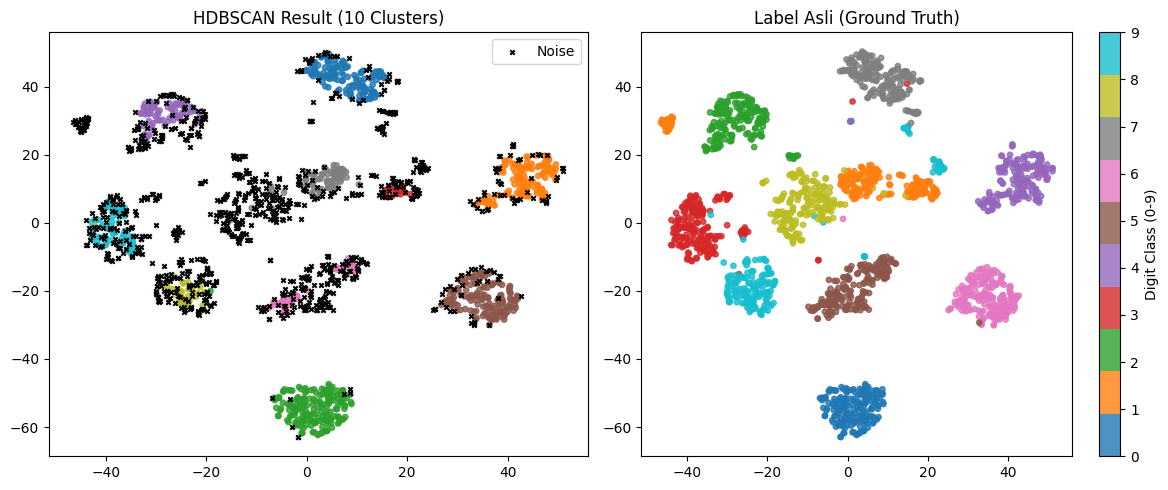

In [2]:
import hdbscan
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

# Load dataset Digits
digits = load_digits()
X = digits.data
y_true = digits.target

# Clustering dengan HDBSCAN
# min_cluster_size menentukan ukuran minimal cluster yang dianggap valid
clusterer = hdbscan.HDBSCAN(min_cluster_size=15)
cluster_labels = clusterer.fit_predict(X)

# - Jumlah cluster yang terbentuk (di luar noise)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

# - Banyaknya noise (label -1)
n_noise = list(cluster_labels).count(-1)

print(f"Jumlah cluster terbentuk : {n_clusters}")
print(f"Banyaknya noise         : {n_noise}")

# - Visualisasi menggunakan t-SNE (reduksi dari 64D ke 2D)
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(12, 5))

# Plot Hasil HDBSCAN
plt.subplot(1, 2, 1)
plt.scatter(
    X_embedded[cluster_labels != -1, 0],
    X_embedded[cluster_labels != -1, 1],
    c=cluster_labels[cluster_labels != -1],
    cmap="tab10",
    s=15,
    alpha=0.8,
)
plt.scatter(
    X_embedded[cluster_labels == -1, 0],
    X_embedded[cluster_labels == -1, 1],
    color="black",
    marker="x",
    s=10,
    label="Noise",
)
plt.title(f"HDBSCAN Result ({n_clusters} Clusters)")
plt.legend()

# Plot Label Asli Dataset (0-9)
plt.subplot(1, 2, 2)
scatter = plt.subplot(1, 2, 2).scatter(
    X_embedded[:, 0], X_embedded[:, 1], c=y_true, cmap="tab10", s=15, alpha=0.8
)
plt.colorbar(scatter, label="Digit Class (0-9)")
plt.title("Label Asli (Ground Truth)")

plt.tight_layout()
plt.show()

### Analisis Singkat untuk Laporan:

1. **Jumlah Klaster vs Label Asli**:
    Dataset Digits memiliki 10 kelas asli (angka 0 sampai 9). HDBSCAN berhasil mengelompokkan sebagian besar angka yang bentuknya sangat khas (seperti angka 0, 1, atau 6) ke dalam klasternya masing-masing secara akurat.

2. **Deteksi Noise**:
    Beberapa gambar angka yang gaya tulisannya ambigu (misalnya angka 1 yang mirip 7, atau 3 yang mirip 8) terdeteksi sebagai noise (label -1). Ini menunjukkan keunggulan HDBSCAN yang tidak memaksakan data berisiko tinggi untuk masuk ke klaster tertentu.